# Memory Usage Analysis Across Workflows and Datasets

This notebook analyzes memory usage of configurations across different 
workflow-dataset combinations. We compute:
- Percentiles (90th, 95th, max) for successful runs
- Boxplot statistics for runs with anticipated memory exceeding a threshold
- Percentages of failed configurations

**Note:** You need to first run the `python -m experiments.debugging.download_data` script to download the data.

In [1]:
from pathlib import Path
from typing import List, Tuple
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from lcdb import ResultSet

WORKFLOW_CLASSES = [
    "lcdb.workflow.sklearn.KNNWorkflow",
    #"lcdb.workflow.sklearn.LibLinearWorkflow",
    #"lcdb.workflow.sklearn.LibSVMWorkflow",
    #"lcdb.workflow.sklearn.TreesEnsembleWorkflow",
    #"lcdb.workflow.xgboost.XGBoostWorkflow",
]

# IO paths
DATA_DIR = Path("./data")
OUTPUT_DIR = DATA_DIR / "memory_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COMBINED_P90 = OUTPUT_DIR / "p90_memory_by_workflow_dataset.csv"
COMBINED_BINS = OUTPUT_DIR / "memory_bins_all_workflows.csv"
SUCCESSFUL_STATS = OUTPUT_DIR / "successful_memory_stats.csv"
ANTICIPATED_STATS = OUTPUT_DIR / "anticipated_memory_stats.csv"

# Node / core layout (Surf Snellius -- Genoa partition)
NODE_MEM_GB = 336.0
NODE_CORES = 192

# Binning baseline
BASELINE_MIN_GB = 1.7    # ≤1.7 = full-node bin
INCLUDE_ANTICIPATED_ERRORS = True

In [2]:
def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)

def load_workflow_results(wf: str, data_dir: Path) -> ResultSet:
    f = data_dir / f"{wf}.jsonl"
    if not f.exists():
        print(f"[WARN] Missing CSV for workflow: {wf} (expected {f})")
        return None
    rs = ResultSet.read_jsonl(f)
    #rs._unpack_build_issues()
    #rs.apply(extract_anticipated_memory)
    return rs

def _floor_one_decimal(x: float) -> float:
    return math.floor(x * 10.0) / 10.0

def get_cores(memory_per_core_gb: float, number_of_nodes: int = 1) -> int:
    total_memory = NODE_MEM_GB * number_of_nodes
    total_cores = NODE_CORES * number_of_nodes
    if memory_per_core_gb <= 0:
        return 0
    max_by_mem = int(total_memory // memory_per_core_gb)
    return int(min(max_by_mem, total_cores))


def _id_sortable(series: pd.Series):
    try:
        vals = pd.to_numeric(series, errors="coerce").dropna().astype(int).tolist()
        return sorted(set(vals))
    except Exception:
        return sorted(set(series.astype(str)))

In [3]:
# 1) Load all workflow CSVs
dfs = [load_workflow_results(wf, DATA_DIR) for wf in WORKFLOW_CLASSES]
dfs = [d for d in dfs if d is not None and not d.empty]
if not dfs:
    raise FileNotFoundError("No workflow CSVs found in DATA_DIR.")
rs = ResultSet.concat(dfs)

In [4]:
def get_df_with_memory_stats_per_dataset_workflow_combination(rs: ResultSet) -> pd.DataFrame:

    rows = []
    for workflow, rs_workflow in rs.group_by_workflow():
        for openmlid, rs_dataset in rs_workflow.group_by_dataset():

            # raw runtimes and memory peaks of all runs for this dataset/workflow combination
            runtimes = np.array([row["experiment_metadata"]["timestamp_end"] - row["experiment_metadata"]["timestamp_start"] for row in rs_dataset])
            memory_peaks = np.array([row["memory_max"] / 1024**3 for row in rs_dataset])
            memory_kills_anticipated = np.array([row["anticipated memory overflow"] for row in rs_dataset])
            memory_kills_executed = np.array(["error" in row and row["error"] is not None and row["error"] == "F_memory_limit_exceeded" for row in rs_dataset])
            anticipated_memory_requirement = np.array([row["anticipated_memory"] for row in rs_dataset])
            
            # determine memory limit
            configured_memory_limits = [r["memory_limit"] for r in rs_dataset if "memory_limit" in r and r["memory_limit"] is not None]
            if configured_memory_limits:
                assert min(configured_memory_limits) == max(configured_memory_limits)
                memory_limit = min(configured_memory_limits)
            else:
                memory_limit = np.nan
            configured_memory_limit = memory_limit / 1024**3

            # determine memory used on average for loading the data
            used_memory_for_data_loading = np.round(np.mean([row["memory_data"] for row in rs_dataset if "memory_data" in row and row["memory_data"] is not None]), 2)

            # summary statistics
            memory_mean_usage = np.round(np.mean(memory_peaks), 2)
            max_memory_peak = np.round(np.max(memory_peaks), 2)
            anticipated_memory_requirement = [v for v in anticipated_memory_requirement if v is not None]
            max_foreseen_memory_peak = np.round(max(max_memory_peak, max(anticipated_memory_requirement) if anticipated_memory_requirement else 0), 2)
            frac_memory_killed = np.mean(memory_kills_executed)
            frac_anticipated_memory_issue = np.mean(memory_kills_anticipated)

            # append the row to output dataframe
            rows.append([workflow, openmlid, runtimes, memory_peaks, memory_kills_anticipated, memory_kills_executed, anticipated_memory_requirement, configured_memory_limit, used_memory_for_data_loading, memory_mean_usage, max_memory_peak, max_foreseen_memory_peak, frac_anticipated_memory_issue, frac_memory_killed])
    
    # return dataframe
    return pd.DataFrame(rows, columns=["workflow", "openmlid", "runtimes", "memory_peaks", "memory kills anticipated", "memory kills executed", "anticipated memory requirement", "memory limit", "memory data", "memory mean peak", "memory max peak", "memory max foreseen peak", "avg num memory kills anticipated", "avg num memory kills executed"])

df = get_df_with_memory_stats_per_dataset_workflow_combination(rs)
df

,workflow,openmlid,runtimes,memory_peaks,memory kills anticipated,memory kills executed,anticipated memory requirement,memory limit,memory data,memory mean peak,memory max peak,memory max foreseen peak,avg num memory kills anticipated,avg num memory kills executed
0,lcdb.workflow.sklearn.KNNWorkflow,3,"[12.152787208557129, 4.378344297409058, 141.76...","[0.3287391662597656, 0.4611854553222656, 0.403...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",[],2.0,0.10,0.41,0.60,0.60,0.00,0.00
1,lcdb.workflow.sklearn.KNNWorkflow,12,"[5.669684171676636, 6.269850969314575, 6.47008...","[0.409210205078125, 0.38687896728515625, 0.376...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",[],21.0,0.10,0.82,4.50,4.50,0.00,0.00
2,lcdb.workflow.sklearn.KNNWorkflow,23,"[2.6237831115722656, 2.538283109664917, 2.5966...","[0.34203338623046875, 0.320526123046875, 0.316...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",[],2.0,0.10,0.33,0.39,0.39,0.00,0.00
3,lcdb.workflow.sklearn.KNNWorkflow,31,"[2.058866262435913, 2.1822316646575928, 2.1515...","[0.3272552490234375, 0.32834625244140625, 0.31...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",[],2.0,0.10,0.34,0.56,0.56,0.00,0.00
4,lcdb.workflow.sklearn.KNNWorkflow,54,"[2.2366113662719727, 2.4369866847991943, 2.420...","[0.3305778503417969, 0.324127197265625, 0.3179...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",[],2.0,0.10,0.33,0.35,0.35,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,lcdb.workflow.sklearn.KNNWorkflow,42734,"[12.984734773635864, 13.588777780532837, 15.58...","[0.505889892578125, 0.4171142578125, 0.5155944...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",[22.253],21.0,0.10,4.98,44.63,44.63,0.01,0.04
67,lcdb.workflow.sklearn.KNNWorkflow,42742,"[63.56217169761658, 135.54657554626465, 154.11...","[9.432498931884766, 2.7945899963378906, 5.7002...","[True, False, False, False, False, False, Fals...","[False, False, True, False, False, False, Fals...",[8.0],5.0,0.71,3.46,9.43,9.43,0.01,0.16
68,lcdb.workflow.sklearn.KNNWorkflow,42746,"[229.5332624912262, 361.1002905368805, 250.001...","[9.077709197998047, 9.172054290771484, 10.9209...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",[],67.0,5.04,11.85,71.92,71.92,0.00,0.01
69,lcdb.workflow.sklearn.KNNWorkflow,42769,"[28.72409415245056, 31.155743837356567, 31.445...","[1.8548049926757812, 2.5239181518554688, 2.483...","[False, False, False, False, False, False, Tru...","[False, False, False, False, True, False, Fals...","[32.0, 32.0, 32.0, 32.0]",21.0,0.60,5.54,33.44,33.44,0.04,0.02


# Some Visualization of Memory Consumption

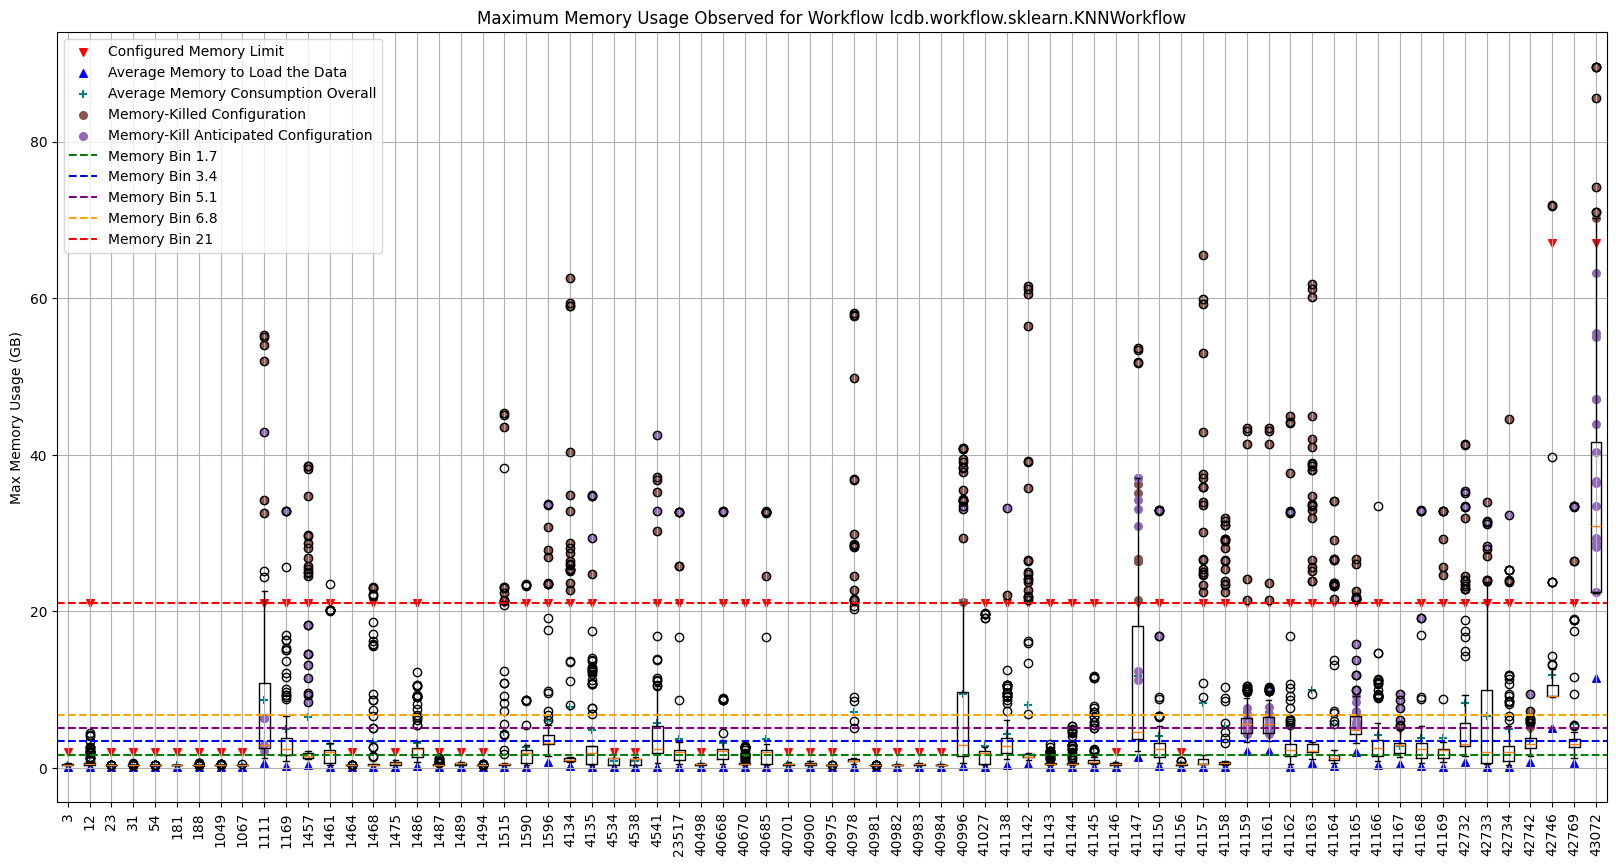

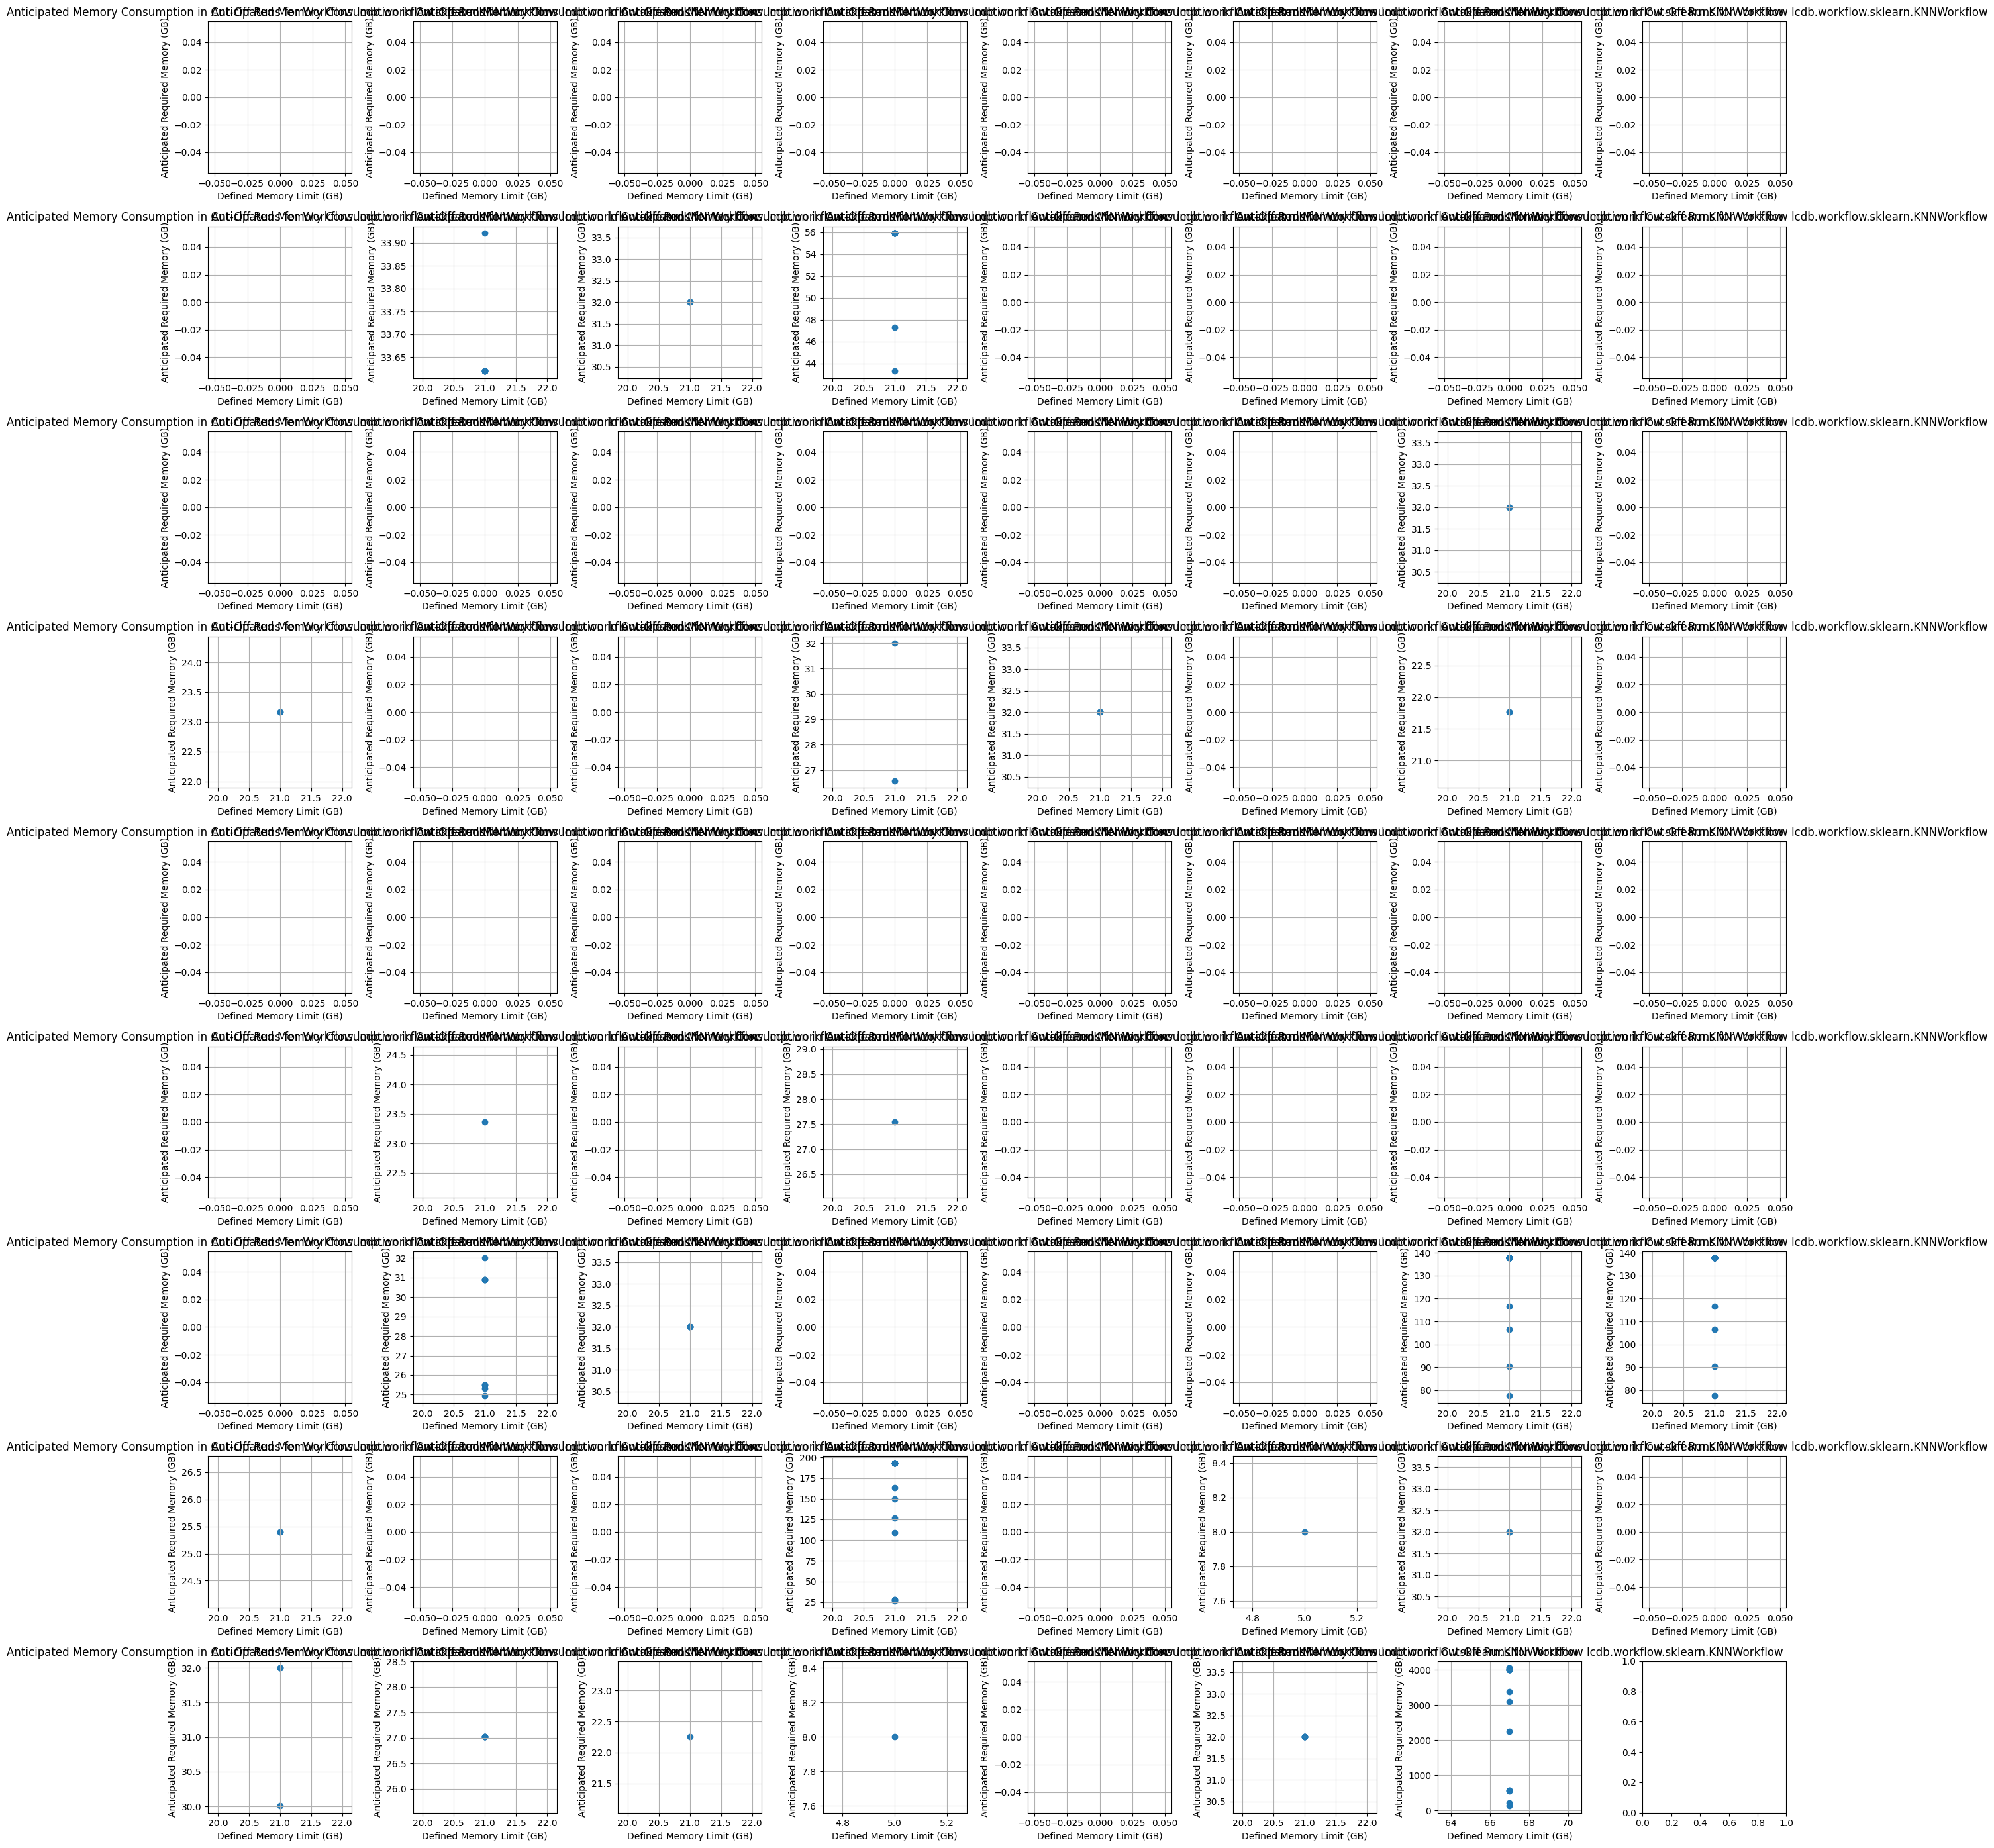

In [5]:
def plot_memory_vs_runtimes(df, n_cols=8):
    datasets = sorted(df["openmlid"].unique())
    for workflow, df_workflow in df.groupby("workflow"):
        
        correlations = []
        max_memory = []
        n_rows = int(np.ceil(len(datasets) / n_cols))
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols + 1, 3 * n_rows + 1))
        for ax, (openmlid, df_dataset) in zip(axs.flatten(), df_workflow.groupby("openmlid")):
            df_dataset = df_dataset.iloc[0]
            
            runtimes = df_dataset["runtimes"]
            memory = df_dataset["memory_peaks"]

            mask2 = df_dataset["memory_kills_anticipated"]
            mask1 = np.ones_like(mask2)#(~mask2 & np.array(["error" in row and row["error"] is not None and "memory" in row["error"].lower() for row in df_dataset]))
            no_mask = ~(mask1 | mask2)
            ax.scatter(runtimes[no_mask], memory[no_mask], label="Normal Runs")
            if np.count_nonzero(mask1) > 0:
                ax.scatter(runtimes[mask1], memory[mask1], label="Memory Killed", color="C5")
            if np.count_nonzero(mask2) > 0:
                ax.scatter(runtimes[mask2], memory[mask2], label="Anticipated Memory Error", color="C4")
            ax.grid()
            corr = np.round(np.corrcoef(runtimes, memory)[0, 1], 2)
            correlations.append(corr)
            max_memory.append(max(memory))
            ax.set_title(f"{openmlid} (corr. {corr})")
            ax.set_xlabel("Runtime (s)")
            ax.set_ylabel("Max Memory Usage (GB)")

        # show correlation vs max memory consumption. This is to understand whether high correlation is relevant for high memory scenarios
        ax = axs[-1, -1]
        ax.scatter(correlations, max_memory)
        ax.set_xlabel("Correlation")
        ax.set_ylabel("Max Memory")
        ax.set_title("Distribution of Correlations")
        ax.grid()

        handles, labels = axs[-1, -2].get_legend_handles_labels()
        fig.legend(handles, labels, bbox_to_anchor=(0.5, 1.02), loc='upper center', ncol=3)
        fig.tight_layout()
        plt.show()


def plot_memory_consumption(df):
    gb_available_per_core = 1.7
    for workflow, df_workflow in df.groupby("workflow"):

        # sort dataframe
        df_workflow = df_workflow.sort_values("openmlid", ascending=True)

        # create figure object
        fig, ax = plt.subplots(figsize=(20, 10))

        # create visual elements per dataset
        ax.boxplot(df_workflow["memory_peaks"])
        x_base = 1 + np.arange(len(df_workflow))
        datasets = df_workflow["openmlid"]
        ax.scatter(x_base, df_workflow["memory limit"], marker="v", s=30, color="red", label="Configured Memory Limit")
        ax.scatter(x_base, df_workflow["memory data"], marker="^", s=30, color="blue", label="Average Memory to Load the Data")
        ax.scatter(x_base, df_workflow["memory mean peak"], marker="+", s=30, color="teal", label="Average Memory Consumption Overall")

        for i, openmlid in zip(x_base, datasets):
            df_dataset = df_workflow[df_workflow["openmlid"] == openmlid].iloc[0]
            killed_configs_on_dataset = df_dataset["memory kills executed"]
            kill_anticipated_configs_on_dataset = df_dataset["memory kills anticipated"]
            ax.scatter(np.count_nonzero(killed_configs_on_dataset) * [i], df_dataset["memory_peaks"][killed_configs_on_dataset], marker="o", s=30, color="C5", label="Memory-Killed Configuration" if i == 1 else None)
            ax.scatter(np.count_nonzero(kill_anticipated_configs_on_dataset) * [i], df_dataset["memory_peaks"][kill_anticipated_configs_on_dataset], marker="o", s=30, color="C4", label="Memory-Kill Anticipated Configuration" if i == 1 else None)

        ax.set_xticks(x_base)
        ax.set_xticklabels(df_workflow["openmlid"], rotation=90)
        ax.set_ylabel("Max Memory Usage (GB)")
        ax.set_title(f"Maximum Memory Usage Observed for Workflow {workflow}")

        # create visual aid elements
        for bin, color in zip(
            [gb_available_per_core, 2 * gb_available_per_core, 3 * gb_available_per_core, 4 * gb_available_per_core, 21],
            ["green", "blue", "purple", "orange", "red"]
        ):
            ax.axhline(bin, color=color, linestyle="--", label=f"Memory Bin {bin}")
        ax.grid()
        ax.legend()
        #ax.set_ylim([0, 2])
        #ax.set_yscale("log")

        # show figure
        plt.show()

def plot_hist_of_max_memory_consumption_over_datasets(df):
    
    for workflow, df_workflow in df.groupby("workflow"):
        fig, axs = plt.subplots(2, 1, figsize=(20, 6))
        sorted_data = sorted(df_workflow["memory max peak"])
        
        ax = axs[0]
        ax.hist(sorted_data, bins=20)
        ax.set_title(f"Maximum Memory Usage Observed for Workflow {workflow}")
        ax.grid()
        
        ax = axs[1]
        cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
        ax.plot(sorted_data, cdf, marker='o')
        x_ticks = [1.7, 3.4, 5.1, 8, 12]
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_ticks)
        ax.set_xlabel('Max Memory Peak')
        ax.set_ylabel('CDF')
        ax.set_title('CDF Plot')
        ax.grid(True)

        #ax.set_ylim([0, 2])
        plt.show()

def plot_anticipated_memory_requirements(df, n_cols=8):
    
    datasets = sorted(df["openmlid"].unique())
    for workflow, df_workflow in df.groupby("workflow"):

        n_rows = int(np.ceil(len(df["openmlid"]) / n_cols))
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols + 1, 3 * n_rows + 1))
        for ax, (openmlid, df_dataset) in zip(axs.flatten(), df.groupby("openmlid")):
            row = df_dataset.iloc[0]
            ax.scatter(len(row["anticipated memory requirement"]) * [row["memory limit"]], row["anticipated memory requirement"])
            #ax.set_xticks(1 + np.arange(len(df)))
            #ax.set_xticklabels(labels, rotation=90)
            #ax.set_yscale("log")
            #ax.set_yticks([2**i for i in range(1, 8)])
            #ax.set_yticklabels([2**i for i in range(1, 8)])
            ax.set_xlabel("Defined Memory Limit (GB)")
            ax.set_ylabel("Anticipated Required Memory (GB)")
            ax.set_title(f"Anticipated Memory Consumption in Cut-Off Runs for Workflow {workflow}")
            ax.grid()
        fig.tight_layout()
        plt.show()

#plot_memory_vs_runtimes(df)
plot_memory_consumption(df)
#plot_hist_of_max_memory_consumption_over_datasets(df)#.filter_datasets([12, 4534, 40670, 41143, 41144, 41167, 42742]))
plot_anticipated_memory_requirements(df)

# Compute Core Assignments

In [ ]:
def compute_core_assignments_based_on_average_and_limited_max(
        df,
        num_of_parallel_max_consumers,
        num_cores=192,
        max_memory=336,
        memory_limit_per_config=64,
        use_forseen_peaks=False
    ):

    rows = []
    for workflow, df_workflow in df.groupby("workflow"):
        for openmlid, df_dataset in df_workflow.groupby("openmlid"):
            
            row = df_dataset.iloc[0]

            # determine the maximum number of cores that can be used in parallel
            max_peak_per_config = min(memory_limit_per_config, min(max_memory, row["memory max foreseen peak"] if use_forseen_peaks else row["memory max peak"]))
            memory_after_max_jobs = max_memory - num_of_parallel_max_consumers * max_peak_per_config
            print(openmlid, max_peak_per_config, memory_after_max_jobs)
            num_cores_designated_for_average_consume = memory_after_max_jobs // row["memory mean peak"]
            max_num_cores_usable_in_parallel = min(int(num_cores_designated_for_average_consume + num_of_parallel_max_consumers), num_cores)

            # append configuration
            memory_limit = max(max_memory / max(1, max_num_cores_usable_in_parallel), max_peak_per_config)
            cores_most_conservative_case = max_memory // memory_limit
            core_gain_abs = int(max_num_cores_usable_in_parallel - cores_most_conservative_case)
            core_gain_rel = np.round(max_num_cores_usable_in_parallel / cores_most_conservative_case - 1, 3)
            rows.append([workflow, openmlid, max_num_cores_usable_in_parallel, cores_most_conservative_case, memory_limit, core_gain_abs, core_gain_rel])
    return pd.DataFrame(rows, columns=["workflow", "openmlid", "cores", "cores most conservative case", "memory_limit", "absolute core gain", "relative core gain"])

# Visualize Core Assignments

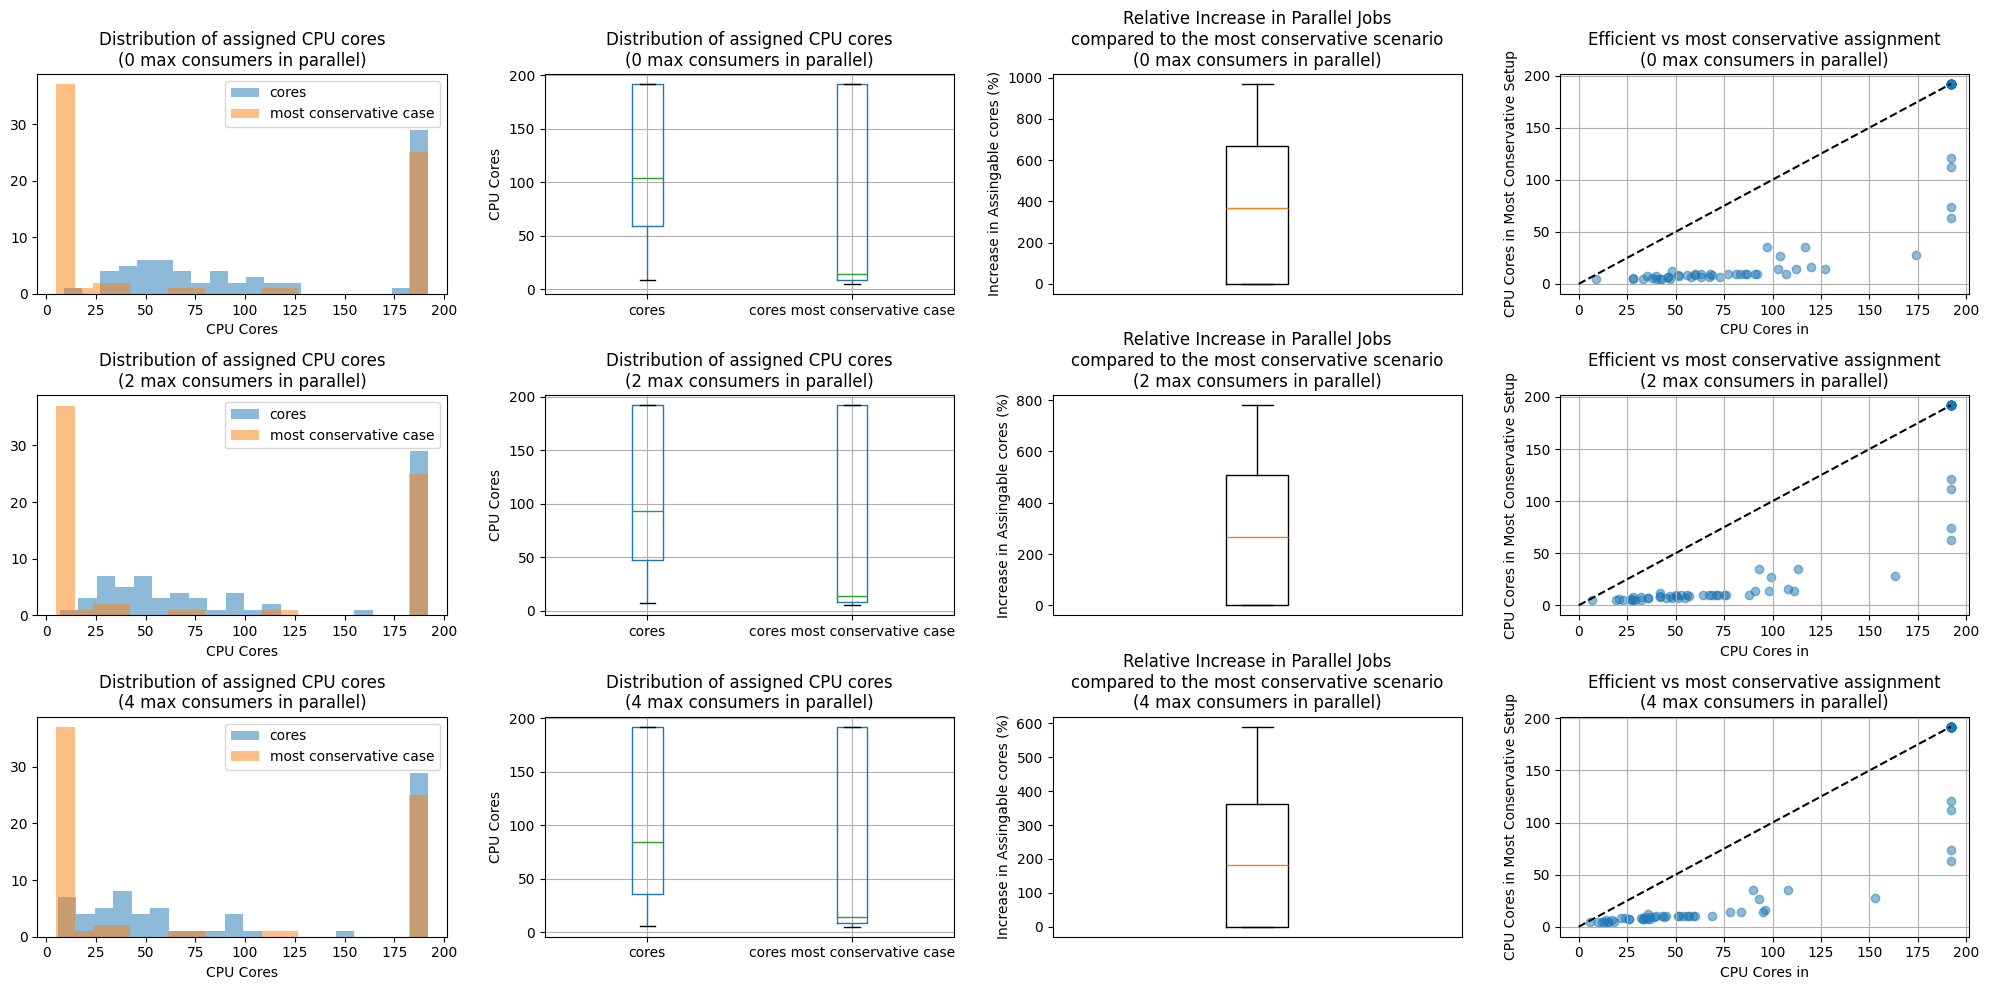

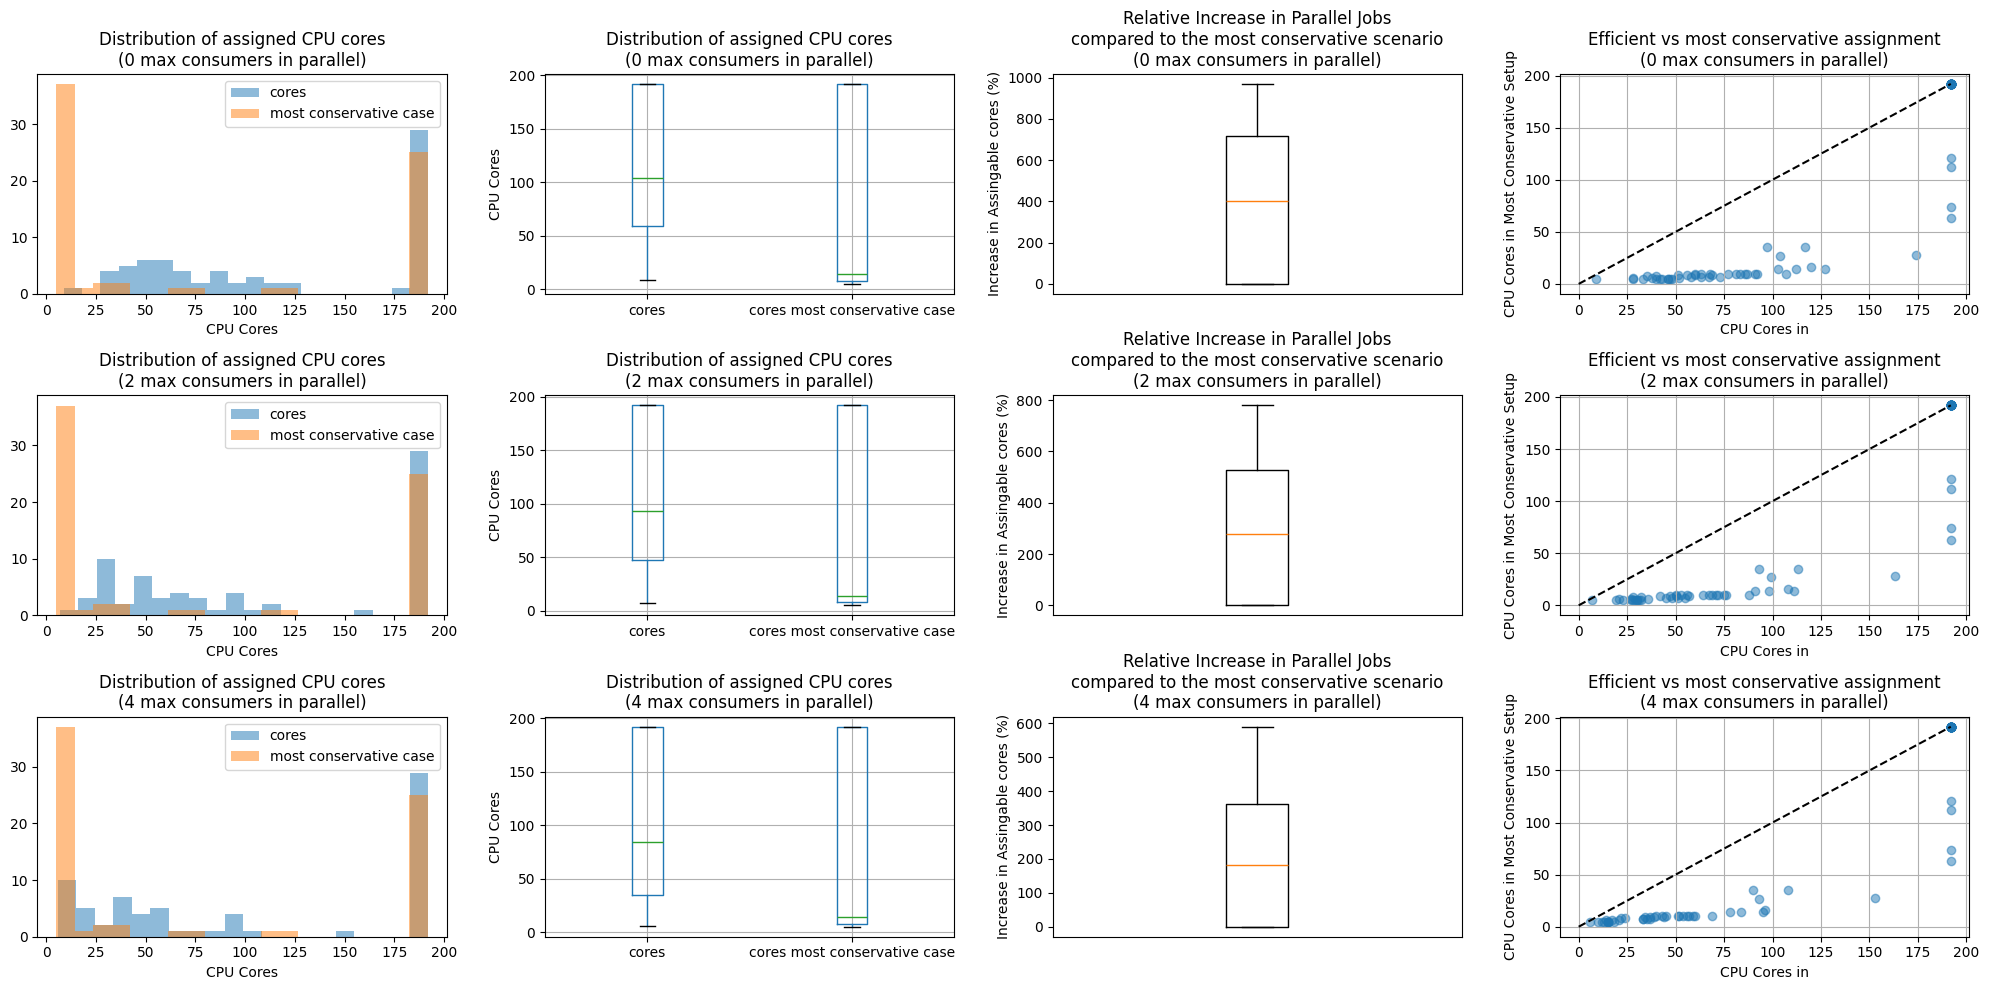

In [7]:
for use_forseen_peaks in [False, True]:
    num_max_consumers_domain = [0, 2, 4]
    fig, axs = plt.subplots(len(num_max_consumers_domain), 4, figsize=(20, 3 * len(num_max_consumers_domain) + 1))
    for ax_row, num_max_consumers in zip(axs, num_max_consumers_domain):
        df_bins = compute_core_assignments_based_on_average_and_limited_max(df, num_of_parallel_max_consumers=num_max_consumers, use_forseen_peaks=use_forseen_peaks)
        ax_row[0].hist(df_bins["cores"], bins=20, alpha=0.5, label="cores")
        ax_row[0].hist(df_bins["cores most conservative case"], bins=20, alpha=0.5, label="most conservative case")
        ax_row[0].set_title(f"Distribution of assigned CPU cores\n({num_max_consumers} max consumers in parallel)")
        ax_row[0].set_xlabel("CPU Cores")
        ax_row[0].legend()

        
        df_bins[["cores", "cores most conservative case"]].boxplot(ax=ax_row[1])
        ax_row[1].set_title(f"Distribution of assigned CPU cores\n({num_max_consumers} max consumers in parallel)")
        ax_row[1].set_ylabel("CPU Cores")

        ax_row[2].boxplot(df_bins["relative core gain"] * 100)
        ax_row[2].set_title(f"Relative Increase in Parallel Jobs\ncompared to the most conservative scenario\n({num_max_consumers} max consumers in parallel)")
        ax_row[2].set_ylabel("Increase in Assingable cores (%)")
        ax_row[2].set_xticks([])

        ax_row[3].scatter(df_bins["cores"], df_bins["cores most conservative case"], alpha=0.5)
        ax_row[3].set_title(f"Efficient vs most conservative assignment\n({num_max_consumers} max consumers in parallel)")
        ax_row[3].set_xlabel("CPU Cores in")
        ax_row[3].set_ylabel("CPU Cores in Most Conservative Setup")
        ax_row[3].plot([0, 192], [0, 192], linestyle="--", color="black")
        ax_row[3].grid()
    fig.tight_layout()
    plt.show()

In [10]:
df_assignments = compute_core_assignments_based_on_average_and_limited_max(
    df,
    num_of_parallel_max_consumers=4,
    max_memory=64,
    use_forseen_peaks=True
)
df_assignments

3 0.6 61.6
12 4.5 46.0
23 0.39 62.44
31 0.56 61.76
54 0.35 62.6
181 0.39 62.44
188 0.61 61.56
1049 0.55 61.8
1067 0.47 62.12
1111 55.33 -157.32
1169 32.8 -67.19999999999999
1457 55.91 -159.64
1461 23.46 -29.840000000000003
1464 0.36 62.56
1468 23.1 -28.400000000000006
1475 0.97 60.12
1486 12.24 15.04
1487 1.27 58.92
1489 0.73 61.08
1494 0.52 61.92
1515 45.39 -117.56
1590 23.46 -29.840000000000003
1596 33.66 -70.63999999999999
4134 62.53 -186.12
4135 34.89 -75.56
4534 1.73 57.08
4538 1.35 58.6
4541 42.52 -106.08000000000001
23517 32.7 -66.80000000000001
40498 0.66 61.36
40668 32.79 -67.16
40670 2.76 52.96
40685 32.82 -67.28
40701 0.69 61.24
40900 0.81 60.76
40975 0.4 62.4
40978 58.1 -168.4
40981 0.42 62.32
40982 0.43 62.28
40983 0.66 61.36
40984 0.43 62.28
40996 40.8 -99.19999999999999
41027 19.82 -15.280000000000001
41138 33.2 -68.80000000000001
41142 61.6 -182.4
41143 3.0 52.0
41144 5.32 42.72
41145 11.68 17.28
41146 0.73 61.08
41147 53.58 -150.32
41150 32.95 -67.80000000000001
41156 

,workflow,openmlid,cores,cores most conservative case,memory_limit,absolute core gain,relative core gain
0,lcdb.workflow.sklearn.KNNWorkflow,3,154,106.0,0.60,48,0.453
1,lcdb.workflow.sklearn.KNNWorkflow,12,60,14.0,4.50,46,3.286
2,lcdb.workflow.sklearn.KNNWorkflow,23,192,164.0,0.39,28,0.171
3,lcdb.workflow.sklearn.KNNWorkflow,31,185,114.0,0.56,71,0.623
4,lcdb.workflow.sklearn.KNNWorkflow,54,192,182.0,0.35,10,0.055
...,...,...,...,...,...,...,...
66,lcdb.workflow.sklearn.KNNWorkflow,42734,-19,1.0,64.00,-20,-20.000
67,lcdb.workflow.sklearn.KNNWorkflow,42742,11,6.0,9.43,5,0.833
68,lcdb.workflow.sklearn.KNNWorkflow,42746,-13,1.0,64.00,-14,-14.000
69,lcdb.workflow.sklearn.KNNWorkflow,42769,-9,1.0,64.00,-10,-10.000
